# Checking `miepython` resonate modes

A concern using the a pre-made package is the individual Mie modes of a particle is not accessable. This is not entirlly required for the solving/fitting particle size BUT access to the particles resonate modes allow for more indepth analysis using the same tool set.

This notebook is intended to show how the different modes of the particles can be accessed through the `miepython` package.

In [2]:
from src import lambda_interpolate as interp
import numpy as np
import matplotlib.pyplot as plt
import miepython as mie
import pandas as pd

In [32]:
material = "materials/silicon.csv" # Amorphous Silicon - Pierce 1972

refrative_index_df = pd.read_csv(material, delimiter = ",", header = 0, names = ["wl", "n", "k"], dtype = float)

# interpolating refrative index before computing Mie spectra
wl_step = 5 # nm step size between each wl sample
wl = np.arange(200, 1200, wl_step)*1e-3 # in microns

n, k = interp.wvl_interpolation(wl, 
                                # Access pd.Series diretly from the df
                                refrative_index_df['wl'], 
                                refrative_index_df['n'],
                                refrative_index_df['k'],
                                )

m = n - 1.0j * k # complex refrative index

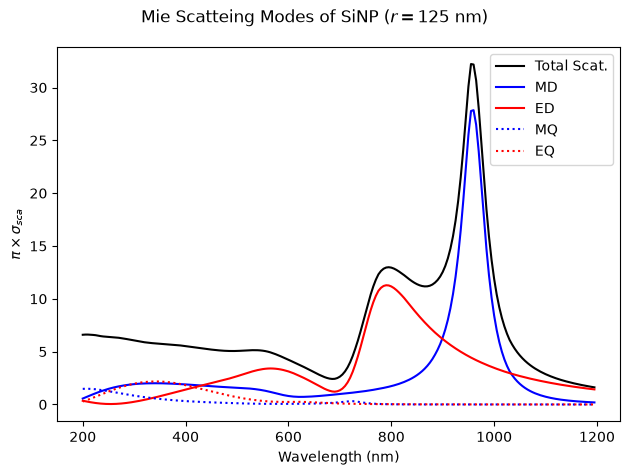

In [68]:
# SOURCE: https://miepython.readthedocs.io/en/latest/13_resonance.html#Non-absorbing-spheres

#  NOTE: I lke plotting the MD mode first as it is always the strongest mode (findamental)

# Size of silicon particle
radii = 0.125 # in microns 
x = 2 * np.pi * radii / wl

fig, ax = plt.subplots()

qext, qsca, qback, g = mie.efficiencies_mx(m, x, 0)
ax.plot(wl * 1e3, qsca * np.pi, "k", label="Total Scat.")

# Magnetic Dipole (b1)
qext, qsca, qback, g = mie.efficiencies_mx(m, x, 1, e_field=False)
ax.plot(wl * 1e3, qsca * np.pi, "b", label="MD")

# Electric Dipole (a1)
qext, qsca, qback, g = mie.efficiencies_mx(m, x, 1, e_field=True)
ax.plot(wl * 1e3, qsca * np.pi, "r", label="ED")

# Magnetic Quadrupoles (b2)
qext, qsca, qback, g = mie.efficiencies_mx(m, x, 2, e_field=False)
ax.plot(wl * 1e3, qsca * np.pi, "b:", label="MQ")

# Electric Quadrupoles (a2)
qext, qsca, qback, g = mie.efficiencies_mx(m, x, 2, e_field=True)
ax.plot(wl * 1e3, qsca * np.pi, "r:", label="EQ")

ax.legend()
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$\pi \times \sigma_{sca}$')
fig.suptitle(f'Mie Scatteing Modes of SiNP ($r={radii*1e3:.0f}$ nm)')

fig.tight_layout()

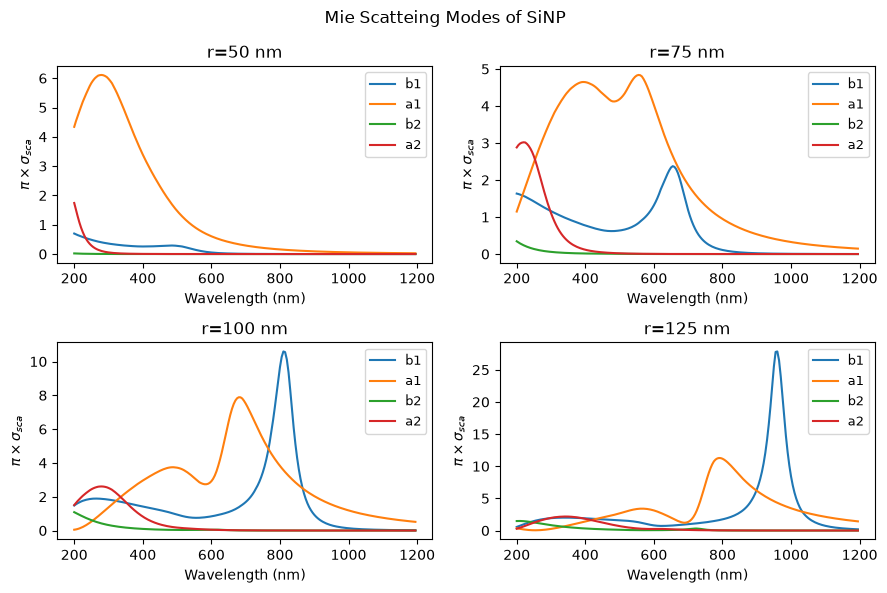

In [67]:
modes = [False, True] # control the e-field pram

# Size of silicon particle
radius = [0.05, 0.075, 0.1, 0.125] # in microns 

fig, axes = plt.subplots(2,2, figsize=(9,6))
ax_flat=axes.flatten()

for p, radii in enumerate(radius):
    x = 2 * np.pi * radii / wl
    for i in range(1,3):
        for mode in modes:

            if mode:
                label = f'a{i}'
            else:
                label = f'b{i}'

            qext, qsca, qback, g = mie.efficiencies_mx(m, x, i, e_field=mode)
            ax_flat[p].plot(wl * 1e3, qsca * np.pi, label=label)

    # ax.legend()
    ax_flat[p].set_ylabel(r'$\pi \times \sigma_{sca}$')
    ax_flat[p].set_xlabel(r'Wavelength (nm)')
    ax_flat[p].set_title(f'r={radii*1e3:.0f} nm')
    ax_flat[p].legend(loc='upper right', fontsize=9)
    
fig.suptitle(f'Mie Scatteing Modes of SiNP')
fig.tight_layout()

## Directional Scatting of Mie Modes

